# MODEL TRAINING and EVALUATION

# Train logistic Regression on TF-IDF Features, Evaluate Performance

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'..\dataset\WELFake_Cleaned.csv')

X = df['Cleaned']
Y = df['label']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 42, stratify = Y
)

vectorizer = joblib.load(r'..\models\tfidf_vectorizer.pkl')

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [3]:
X_train_tfidf.shape

(57637, 5000)

In [4]:
X_test_tfidf.shape

(14410, 5000)

In [5]:
model = LogisticRegression(
    max_iter = 1000,
    random_state = 42,
    n_jobs = -1
)

model.fit(X_train_tfidf, Y_train)

c:\Users\vansh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [6]:
Y_pred = model.predict(X_test_tfidf)
Y_pred_prob = model.predict_proba(X_test_tfidf)

Sample Predicted Labels:


In [7]:
Y_pred[:10]

array([1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

Sample Actual Labels:

In [8]:
Y_test.values[:10]

array([1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

Sample Fake Probability Scores:

In [9]:
Y_pred_prob[:5, 1].round(3)

array([0.682, 0.874, 0.03 , 0.065, 0.939])

In [10]:
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
print(f"MODEL EVALUATION RESULTS")
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")

MODEL EVALUATION RESULTS
  Accuracy  : 0.9525
  Precision : 0.9459
  Recall    : 0.9626
  F1 Score  : 0.9541


Detailed Classification Report

In [11]:
classification_report(Y_test, Y_pred, target_names=['Real', 'Fake'])

'              precision    recall  f1-score   support\n\n        Real       0.96      0.94      0.95      7006\n        Fake       0.95      0.96      0.95      7404\n\n    accuracy                           0.95     14410\n   macro avg       0.95      0.95      0.95     14410\nweighted avg       0.95      0.95      0.95     14410\n'

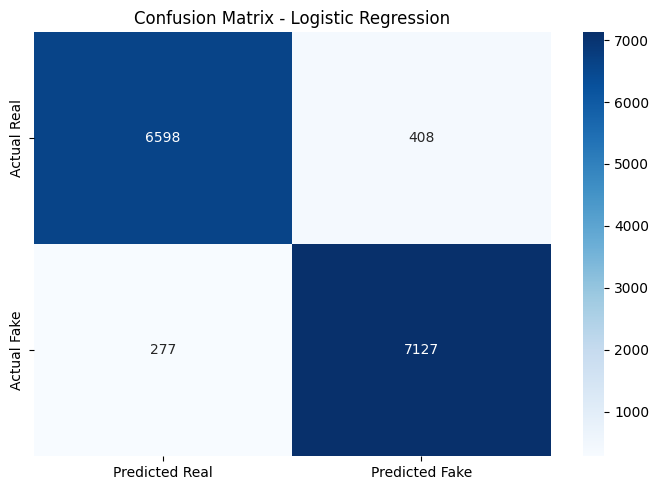

In [12]:
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm, annot=True,fmt='d',cmap='Blues',xticklabels=['Predicted Real','Predicted Fake'],yticklabels=['Actual Real','Actual Fake']
)
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.savefig('../screenshots/confusion_matrix.png', dpi = 150)
plt.show()

In [13]:
print(f"True Negatives (Real Correctly Identified): {cm[0][0]}")
print(f"False Positives (Real misclassified as Fake): {cm[0][1]}")
print(f"False Negatives (Fake misclassified as Real): {cm[1][0]}")
print(f"True Positives (Fake Correctly Identified): {cm[1][1]}")

True Negatives (Real Correctly Identified): 6598
False Positives (Real misclassified as Fake): 408
False Negatives (Fake misclassified as Real): 277
True Positives (Fake Correctly Identified): 7127


In [14]:
joblib.dump(model, r'..\models\logistic_regression_model.pkl')

['..\\models\\logistic_regression_model.pkl']